<a href="https://colab.research.google.com/github/Blacklotus89898/ComputerVisionMiscellaneous/blob/main/esce_415_a3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Computer Vision (ECSE 415)
## Assignment 3: Classifiers and Object Recognition

DEADLINE: October 31, 11:59 PM

Name: Steve Chen

ID: 261106847

0. Setup and Environment

In [25]:
# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import os
import pandas as pd

In [26]:
# Loading from the drive
from google.colab import drive
drive.mount('/content/drive')

# Part 1
base_path1 = "/content/drive/MyDrive/ECSE415/Q1"


# base_path = "/content/drive/MyDrive/ECSE415/Q1"
# img_array = []
# for i in range(1, 9):
#   img_path = os.path.join(base_path, f"chihuahua-{i}.jpg")
#   img = cv2.imread(img_path)
#   img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#   img_array.append(img_gray)

# Part 2
base_path2 = "/content/drive/MyDrive/ECSE415/Q2"
# sveti1_path = os.path.join(base_path, "sveti_stefan_view1.png")
# sveti2_path = os.path.join(base_path, "sveti_stefan_view2.png")
# sveti1_img = cv2.imread(sveti1_path)
# sveti2_img = cv2.imread(sveti2_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#1	Face Detection [50 points]

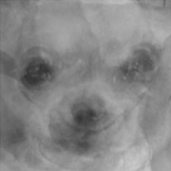

In [27]:
# 1. Load image:
img_array = []

for i in range(1, 9):
    img_path = os.path.join(base_path1, f"chihuahua-{i}.jpg")
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not read {img_path}")
        continue
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_array.append(img_gray)

# 2. Mean Face
target_size = (img_array[0].shape[1], img_array[0].shape[0])  # (width, height)
img_array = [cv2.resize(x, target_size) for x in img_array]

stacked = np.stack(img_array, axis=0)
mean_image = np.mean(stacked, axis=0)

mean_image_uint8 = np.clip(mean_image, 0, 255).astype(np.uint8)
cv2_imshow(mean_image_uint8)

Data matrix shape: (8, 29241)
Eigenvalues: [ 2.8501e+07  1.9771e+07  1.2814e+07  1.0507e+07  9.4664e+06  5.8252e+06  4.8126e+06 -6.7374e-09]
Reduced representation shape: (8, 6)


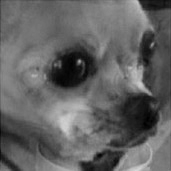

In [28]:

# def pca_images(imgs, num_components=None):
#     # imgs shape: (n_images, h, w)
#     n, h, w = imgs.shape
#     X = imgs.reshape(n, h * w).astype(np.float32)  # lazy flatten

#     # Mean center
#     X_meaned = X - np.mean(X, axis=0)

#     # Compute SVD (instead of huge covariance matrix)
#     U, S, Vt = np.linalg.svd(X_meaned, full_matrices=False)

#     if num_components is not None:
#         U = U[:, :num_components]
#         S = S[:num_components]
#         Vt = Vt[:num_components, :]

#     X_reduced = np.dot(U, np.diag(S))
#     eigenvalues = (S ** 2) / (n - 1)
#     eigenvectors = Vt.T  # principal components as flattened images

#     return X_reduced, eigenvalues, eigenvectors, (h, w)

# # Suppose img_array = list of grayscale images (all same size)
# stacked = np.stack(img_array, axis=0)  # (n, h, w)

# X_pca, eigenvalues, eigenvectors, shape = pca_images(stacked, num_components=5)

# print("Eigenvalues:", eigenvalues[:5])
# print("X_pca shape:", X_pca.shape)


# === Step 3: Flatten images and center data ===
num_images, h, w = stacked.shape
X = stacked.reshape(num_images, -1)  # shape: (8, h*w)
mean_vector = mean_image.flatten()
X_centered = X - mean_vector

print("Data matrix shape:", X_centered.shape)

# === Step 4: Compute small covariance matrix (8x8 trick) ===
# Because num_pixels >> num_images, we use the compact form
C_small = np.dot(X_centered, X_centered.T) / (num_images - 1)  # shape (8,8)

# === Step 5: Eigen decomposition ===
eigvals, eigvecs_small = np.linalg.eig(C_small)

# Sort by descending eigenvalues
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs_small = eigvecs_small[:, idx]

print("Eigenvalues:", eigvals)

# === Step 6: Map eigenvectors back to image space ===
eigvecs_large = np.dot(X_centered.T, eigvecs_small)
eigvecs_large = eigvecs_large / np.linalg.norm(eigvecs_large, axis=0)  # normalize

# === Step 7: Visualize top eigenfaces ===
num_components_to_show = 4
plt.figure(figsize=(10, 4))
for i in range(num_components_to_show):
    eigenface = eigvecs_large[:, i].reshape(h, w)
    plt.subplot(1, num_components_to_show, i + 1)
    plt.imshow(eigenface, cmap='gray')
    plt.title(f"PC {i+1}")
    plt.axis('off')
plt.show()

# === Step 8: Project images onto top K eigenvectors ===
k = 6
W = eigvecs_large[:, :k]
X_reduced = np.dot(X_centered, W)  # shape: (8, k)
print("Reduced representation shape:", X_reduced.shape)

# === Step 9 (Optional): Reconstruct image from PCA ===
recon = np.dot(X_reduced[0], W.T) + mean_vector
recon_image = recon.reshape(h, w)
cv2_imshow(np.clip(recon_image, 0, 255).astype(np.uint8))



In [29]:
# ---------- Explained variance and selecting k ----------
# Make sure eigenvalues are non-negative reals (numerical)
eigvals = np.array(eigvals, dtype=np.float64)
eigvals[eigvals < 0] = 0.0    # clip tiny negatives that come from numerical error

total_var = np.sum(eigvals)
explained_ratio = eigvals / total_var
cumulative = np.cumsum(explained_ratio)

# find smallest k for >= 90% and >= 95%
k_90 = int(np.searchsorted(cumulative, 0.90)) + 1
k_95 = int(np.searchsorted(cumulative, 0.95)) + 1

print(f"Number of images (n) = {num_images}, max possible nonzero PCs = {num_images}")
print(f"Total variance (sum eigenvalues): {total_var:.4f}")
print(f"k for >=90% explained variance: {k_90}")
print(f"k for >=95% explained variance: {k_95}")

# ---------- Plot cumulative explained variance ----------
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(cumulative)+1), cumulative*100, marker='o')
plt.axhline(90, color='gray', linestyle='--', linewidth=1)
plt.axhline(95, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Number of principal components k')
plt.ylabel('Cumulative explained variance (%)')
plt.title('Cumulative explained variance vs k')
plt.grid(True)
plt.xticks(np.arange(1, len(cumulative)+1))
plt.ylim(0, 100)
plt.show()

# ---------- Function to compute reconstruction error and reconstructions ----------
def reconstruct_and_error(k):
    W = eigvecs_large[:, :k]            # (d, k)
    coeffs = np.dot(X_centered, W)      # (n, k)
    X_recon = np.dot(coeffs, W.T) + mean_vector  # (n, d)
    # MSE per image (mean squared error over pixels)
    mse_per_image = np.mean((X - X_recon)**2, axis=1)
    mse_mean = np.mean(mse_per_image)
    return X_recon, mse_per_image, mse_mean

Xrec_90, mse_per_image_90, mse_mean_90 = reconstruct_and_error(k_90)
Xrec_95, mse_per_image_95, mse_mean_95 = reconstruct_and_error(k_95)

print(f"Average reconstruction MSE with k={k_90}: {mse_mean_90:.4f}")
print(f"Average reconstruction MSE with k={k_95}: {mse_mean_95:.4f}")

# Optionally compute normalized error relative to image variance
image_var = np.mean(np.var(X, axis=1))  # average of per-image variance
print(f"Average per-image variance: {image_var:.4f}")
print(f"Normalized MSE (k={k_90}): {mse_mean_90 / image_var:.4f}")
print(f"Normalized MSE (k={k_95}): {mse_mean_95 / image_var:.4f}")

# ---------- Visualize original / mean / reconstructions for a few examples ----------
num_show = min(4, num_images)
indices = list(range(num_show))

plt.figure(figsize=(12, 4*(3)))
for i, idx_img in enumerate(indices):
    orig = X[idx_img].reshape(h, w)
    mean_img = mean_vector.reshape(h, w)
    rec90 = Xrec_90[idx_img].reshape(h, w)
    rec95 = Xrec_95[idx_img].reshape(h, w)

    # Original
    plt.subplot(num_show, 4, i*4 + 1)
    plt.imshow(np.clip(orig,0,255).astype(np.uint8), cmap='gray')
    plt.title(f"Orig #{idx_img}")
    plt.axis('off')

    # Mean
    plt.subplot(num_show, 4, i*4 + 2)
    plt.imshow(np.clip(mean_img,0,255).astype(np.uint8), cmap='gray')
    plt.title("Mean")
    plt.axis('off')

    # Recon k_90
    plt.subplot(num_show, 4, i*4 + 3)
    plt.imshow(np.clip(rec90,0,255).astype(np.uint8), cmap='gray')
    plt.title(f"Recon k={k_90}\nMSE={mse_per_image_90[idx_img]:.1f}")
    plt.axis('off')

    # Recon k_95
    plt.subplot(num_show, 4, i*4 + 4)
    plt.imshow(np.clip(rec95,0,255).astype(np.uint8), cmap='gray')
    plt.title(f"Recon k={k_95}\nMSE={mse_per_image_95[idx_img]:.1f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Number of images (n) = 8, max possible nonzero PCs = 8
Total variance (sum eigenvalues): 91698011.5000
k for >=90% explained variance: 6
k for >=95% explained variance: 7
Average reconstruction MSE with k=6: 144.0114
Average reconstruction MSE with k=7: 0.0000
Average per-image variance: 2934.2679
Normalized MSE (k=6): 0.0491
Normalized MSE (k=7): 0.0000


In [30]:
# Load the muffin image

muffin_array = []
for i in range(1, 9):
    img_path = os.path.join(base_path1, f"muffin-{i}.jpeg")  # base_path2 for muffins
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not read {img_path}")
        continue
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img_gray, (w, h))  # same size as chihuahuas
    muffin_array.append(img_resized)

# 2️⃣ Stack and flatten muffins
muffin_stacked = np.stack(muffin_array, axis=0)
X_muffin = muffin_stacked.reshape(len(muffin_array), -1)  # shape (num_muffins, h*w)

# 3️⃣ Center muffins using *the same* mean as chihuahuas
X_muffin_centered = X_muffin - mean_vector

# 4️⃣ Project onto chihuahua PCA subspace
X_muffin_reduced = np.dot(X_muffin_centered, W)  # shape (num_muffins, k)

print("Muffin projection shape:", X_muffin_reduced.shape)

# 5️⃣ (Optional) Reconstruct muffin images from PCA subspace
X_muffin_reconstructed = np.dot(X_muffin_reduced, W.T) + mean_vector

# visualize one reconstructed muffin
idx = 0
recon = X_muffin_reconstructed[idx].reshape(h, w)
plt.subplot(1, 2, 1)
plt.title("Original Muffin")
plt.imshow(muffin_array[idx], cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Reconstructed (k={k})")
plt.imshow(np.clip(recon, 0, 255).astype(np.uint8), cmap='gray')
plt.axis('off')
plt.show()

Muffin projection shape: (8, 6)


In [31]:
#  Project all chihuahua images onto PCA space
X_chihuahua_reduced = np.dot(X_centered, W)  # shape: (num_chihuahuas, k)
mean_chihuahua_proj = np.mean(X_chihuahua_reduced, axis=0)  # shape: (k,)

# 2️⃣ Compute Euclidean distance of each muffin to mean Chihuahua
distances = np.linalg.norm(X_muffin_reduced - mean_chihuahua_proj, axis=1)

# 3️⃣ Sort distances ascending
sorted_indices = np.argsort(distances)
sorted_distances = distances[sorted_indices]

print("Distances (ascending):", sorted_distances)
print("Sorted muffin indices:", sorted_indices)

# 4️⃣ Optional: visualize muffins sorted by distance
plt.figure(figsize=(12, 4))
for rank, idx in enumerate(sorted_indices):
    plt.subplot(1, len(sorted_indices), rank + 1)
    plt.imshow(muffin_array[idx], cmap='gray')
    plt.title(f"d={sorted_distances[rank]:.1f}")
    plt.axis('off')
plt.suptitle("Muffins sorted by PCA distance to mean Chihuahua face")
plt.show()

Distances (ascending): [     2257.6      3597.5      3618.4        4083      4263.9        4358      5330.9      6617.5]
Sorted muffin indices: [1 0 4 3 5 7 6 2]


Cloning into 'yolov5'...
remote: Enumerating objects: 17639, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 17639 (delta 11), reused 8 (delta 8), pack-reused 17601 (from 3)
Receiving objects: 100% (17639/17639), 16.98 MiB | 24.69 MiB/s, done.
Resolving deltas: 100% (11995/11995), done.
/content/yolov5/yolov5


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-10-27 Python-3.12.12 torch-2.8.0+cu126 CPU

100%|██████████| 14.1M/14.1M [00:00<00:00, 169MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

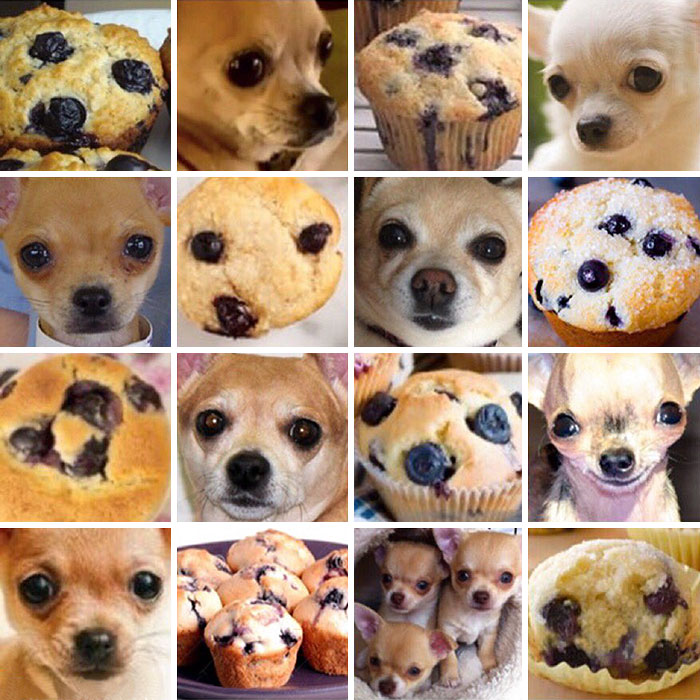

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 700x700 11 dogs, 3 bears, 1 vase, 10 teddy bears
Speed: 11.2ms pre-process, 760.3ms inference, 2.5ms NMS per image at shape (1, 3, 640, 640)


         xmin        ymin        xmax        ymax  confidence  class  \
0    0.850044  526.837341  173.108093  699.316345    0.791991     16   
1    0.000000    2.856457  168.618851  157.018448    0.779481     77   
2  534.666565    0.000000  697.661743  164.809372    0.774679     16   
3  433.241852  530.013855  524.682068  692.171631    0.757174     16   
4  174.613937  176.628540  343.758270  337.433960    0.737699     77   

         name  
0         dog  
1  teddy bear  
2         dog  
3         dog  
4  teddy bear  


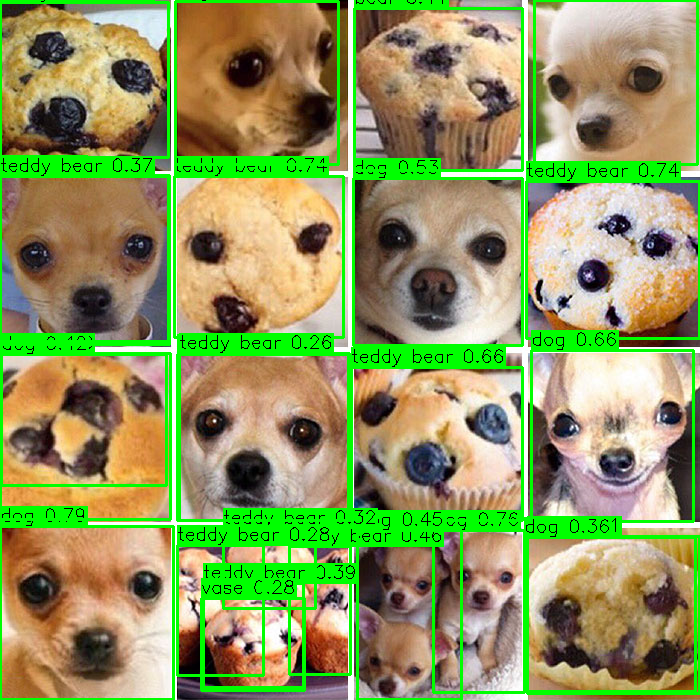

In [32]:
# Load yolo

# Clone YOLOv5 repository
!git clone https://github.com/ultralytics/yolov5
%cd yolov5

# Install dependencies
!pip install -r requirements.txt

import torch
from matplotlib import pyplot as plt
from IPython.display import Image, display

model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

print(model.names)


img_path = os.path.join(base_path1, f"full.jpg")  # base_path2 for muffins
full_img = cv2.imread(img_path)
cv2_imshow(full_img)

# Inference
results = model(full_img)

# Print results
results.print()
# results.show()
# cv2_imshow(full_img)

df = results.pandas().xyxy[0]
print(df.head())

# Make a copy of the original image
img_drawn = full_img.copy()

# Loop over each detection
for i, row in df.iterrows():
    # Coordinates
    xmin, ymin, xmax, ymax = int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])

    # Class name and confidence
    label = f"{row['name']} {row['confidence']:.2f}"

    # Choose color (BGR)
    color = (0, 255, 0)  # green box

    # Draw rectangle
    cv2.rectangle(img_drawn, (xmin, ymin), (xmax, ymax), color, 2)

    # Draw label background
    (text_width, text_height), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
    cv2.rectangle(img_drawn, (xmin, ymin - text_height - baseline), (xmin + text_width, ymin), color, -1)

    # Put text
    cv2.putText(img_drawn, label, (xmin, ymin - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)

# Show the image
cv2_imshow(img_drawn)

# 9. Compare the accuracy of your eigenface-based Chihuahua detector with YOLOv5. Discuss their limitations, and identify which muffin image was the most confusing. Hypothesize why. [5 points]

# 2.	Classifiers [50 points]

In [33]:
# 1. Dataset
# Load image + resize 160 * 160
pokemon_array = ["Bulbasaur", "Charizard", "Dragonite", "Pikachu", "Squirtle"]
pokemon_train_array = {}
pokemon_test_array = {}

# 2️⃣ Load images properly into lists
for pokemon in pokemon_array:
    train_imgs = []
    test_imgs = []

    # Load training images
    for i in range(1, 11):
        img_path = os.path.join(base_path2, f"{pokemon}/train/train_{i}.jpg")
        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ Warning: Could not read {img_path}")
            continue
        img_resized = cv2.resize(img, (160, 160))
        train_imgs.append(img_resized)

    # Load test images
    for i in range(1, 6):
        img_path = os.path.join(base_path2, f"{pokemon}/test/test_{i}.jpg")
        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ Warning: Could not read {img_path}")
            continue
        img_resized = cv2.resize(img, (160, 160))
        test_imgs.append(img_resized)

    pokemon_train_array[pokemon] = train_imgs
    pokemon_test_array[pokemon] = test_imgs

# for pokemon in pokemon_array:
#     imgs = pokemon_train_array[pokemon]
#     tests = pokemon_train_array[pokemon]

#     if len(imgs) == 0:
#         print(f"⚠️ No images found for {pokemon}")
#         continue

#     print(f"\n=== 🧩 {pokemon} ({len(imgs)} images) ===")
#     for i, img in enumerate(imgs):
#         print(f"{pokemon} - train_{i+1}.jpg")
#         cv2_imshow(img)
#     for i, img in enumerate(tests):
#         print(f"{pokemon} - test_{i+1}.jpg")
#         cv2_imshow(img)



In [43]:
img = pokemon_train_array["Charizard"][8]

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# HOG parameters
cell_size = (10, 10)
block_size = (20, 20)
block_stride = (10, 10)
nbins = 9

# Make sure window size is divisible by cell size
win_size = (gray.shape[1] // cell_size[1] * cell_size[1],
            gray.shape[0] // cell_size[0] * cell_size[0])

hog = cv2.HOGDescriptor(_winSize=win_size,
                        _blockSize=block_size,
                        _blockStride=block_stride,
                        _cellSize=cell_size,
                        _nbins=nbins)

# Compute HOG feature vector
h = hog.compute(gray)

print("HOG feature vector length:", len(h))
print("Example values:", h[:10].flatten())

HOG feature vector length: 8100
Example values: [    0.26809    0.021598    0.054706    0.038944     0.04703    0.015518     0.26809     0.19796     0.26809     0.11668]


In [35]:
# 3. SVM
# •	First, train a linear SVM classifier and set the regularization parameter C =1.0.
# •	Train an SVM with the RBF kernel, using any value of γ of your choice.
# •	Train an SVM with the polynomial kernel, using any value of the degree parameter of your choice.


In [36]:
# 4. Random Forest Classifier
# Train 2 random forest

In [37]:
# 5. Testing and Visualization
# Accuracy, confusion matrix

## 6.	Analysis and Discussion
•	Which kernel provided the best results, and what were the optimal hyperparameters?
•	How did the choice of model affect the classification accuracy?
•	Which two Pokémon were most frequently misclassified, and why do you think they were difficult to distinguish?